# LIDC-IDRI Data Exploration

This notebook explores the LIDC-IDRI dataset structure, visualizes CT scans, and analyzes annotations.

> ⚠️ **Fixed version** — The original Cell 1 that deleted all checkpoints has been removed.
> Five issues were corrected: checkpoint deletion bug, XML path mismatch, malignancy distribution
> placeholder, missing nodule centroid overlay, and unused preprocessing comparison function.

In [ ]:
import sys

!{sys.executable} -m pip install --user -r ../requirements.txt


In [7]:
import os

root = '../data/raw/LIDC-IDRI'

for folder in os.listdir(root)[:5]:
    folder_path = os.path.join(root, folder)
    print(folder, "contains:", len(os.listdir(folder_path)), "files")


1.3.6.1.4.1.14519.5.2.1.6279.6001.168037818448885856452592057286 contains: 637 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.428038562098395445838061018440 contains: 540 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.149484561117305919058718221926 contains: 2 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.205174485766424333452131788504 contains: 110 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.663019255629770796363333877035 contains: 261 files


In [22]:
DATA_ROOT = Path('../data/raw/LIDC-IDRI')
XML_ROOT  = Path('../data/raw/annotations/tcia-lidc-xml')

In [8]:
import sys
sys.path.append('../src')

from data_exploration.exploration import LIDCExplorer, visualize_preprocessing_comparison

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

%matplotlib inline


## 1. Dataset Structure Overview

### LIDC-IDRI Organization:
- **DICOM Format**: Each patient has CT scans in DICOM format
- **Multiple Annotations**: Up to 4 radiologists annotated each scan
- **XML Metadata**: Nodule characteristics stored in XML
- **Malignancy Scale**: 1-5 (1=benign, 5=highly malignant)
- **Patient-Level Folders**: LIDC-IDRI-XXXX structure

In [23]:
from pathlib import Path
from collections import Counter

DATA_ROOT = Path('../data/raw/LIDC-IDRI')
RAW_ROOT  = Path('../data/raw')

# 🔍 Find all XML files recursively
xml_files = list(RAW_ROOT.rglob("*.xml"))

print(f"🔍 Total XML files found: {len(xml_files)}")

# ❌ Remove unwanted XMLs inside DICOM root
xml_files = [p for p in xml_files if "LIDC-IDRI" not in str(p.parent)]

print(f"✅ XML files after filtering: {len(xml_files)}")

# 📊 Find the most common parent directory
parent_counts = Counter([p.parent for p in xml_files])

# 🎯 Select the directory with most XML files
XML_ROOT = parent_counts.most_common(1)[0][0] if parent_counts else None

# 🔎 Final validation
print("\n📁 Final Paths:")
print('DICOM root :', DATA_ROOT)
print('XML root   :', XML_ROOT)
print('XML exists :', XML_ROOT.exists() if XML_ROOT else False)

if XML_ROOT:
    xml_list = list(XML_ROOT.rglob("*.xml"))
    print('Total XML files (recursive):', len(xml_list))
    print('Sample XML files:', xml_list[:3])
else:
    print("❌ XML root not found")

🔍 Total XML files found: 2637
✅ XML files after filtering: 1319

📁 Final Paths:
DICOM root : ../data/raw/LIDC-IDRI
XML root   : ../data/raw/annotations/tcia-lidc-xml/188
XML exists : True
Total XML files (recursive): 300
Sample XML files: [PosixPath('../data/raw/annotations/tcia-lidc-xml/188/065.xml'), PosixPath('../data/raw/annotations/tcia-lidc-xml/188/284.xml'), PosixPath('../data/raw/annotations/tcia-lidc-xml/188/049.xml')]


In [24]:
# Initialize explorer
explorer = LIDCExplorer(DATA_ROOT)

# List patients
patients = explorer.list_patients()

print(f'Total patients found: {len(patients)}')
print(f'First 5 patients: {patients[:5]}')


Total patients found: 1018
First 5 patients: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926682752765845212286', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543']


## 2. Load and Visualize CT Scan

In [25]:
# Load a sample patient
if len(patients) > 0:
    patient_id = patients[0]
    print(f'Loading patient: {patient_id}')

    # Load DICOM slices
    slices = explorer.load_dicom_scan(patient_id)
    print(f'Number of slices: {len(slices)}')

    # Convert to HU
    volume_hu = explorer.get_pixels_hu(slices)
    print(f'Volume shape: {volume_hu.shape}')
    print(f'HU range: [{volume_hu.min()}, {volume_hu.max()}]')

    # Get spacing
    spacing = explorer.get_spacing(slices)
    print(f'Voxel spacing (mm): {spacing}')


Loading patient: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Found 194 total DICOM files for 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Selected CT series: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Number of CT slices: 194
Number of slices: 194
Volume shape: (194, 512, 512)
HU range: [-1024, 3071]
Voxel spacing (mm): (2.0, 0.64453125, 0.64453125)


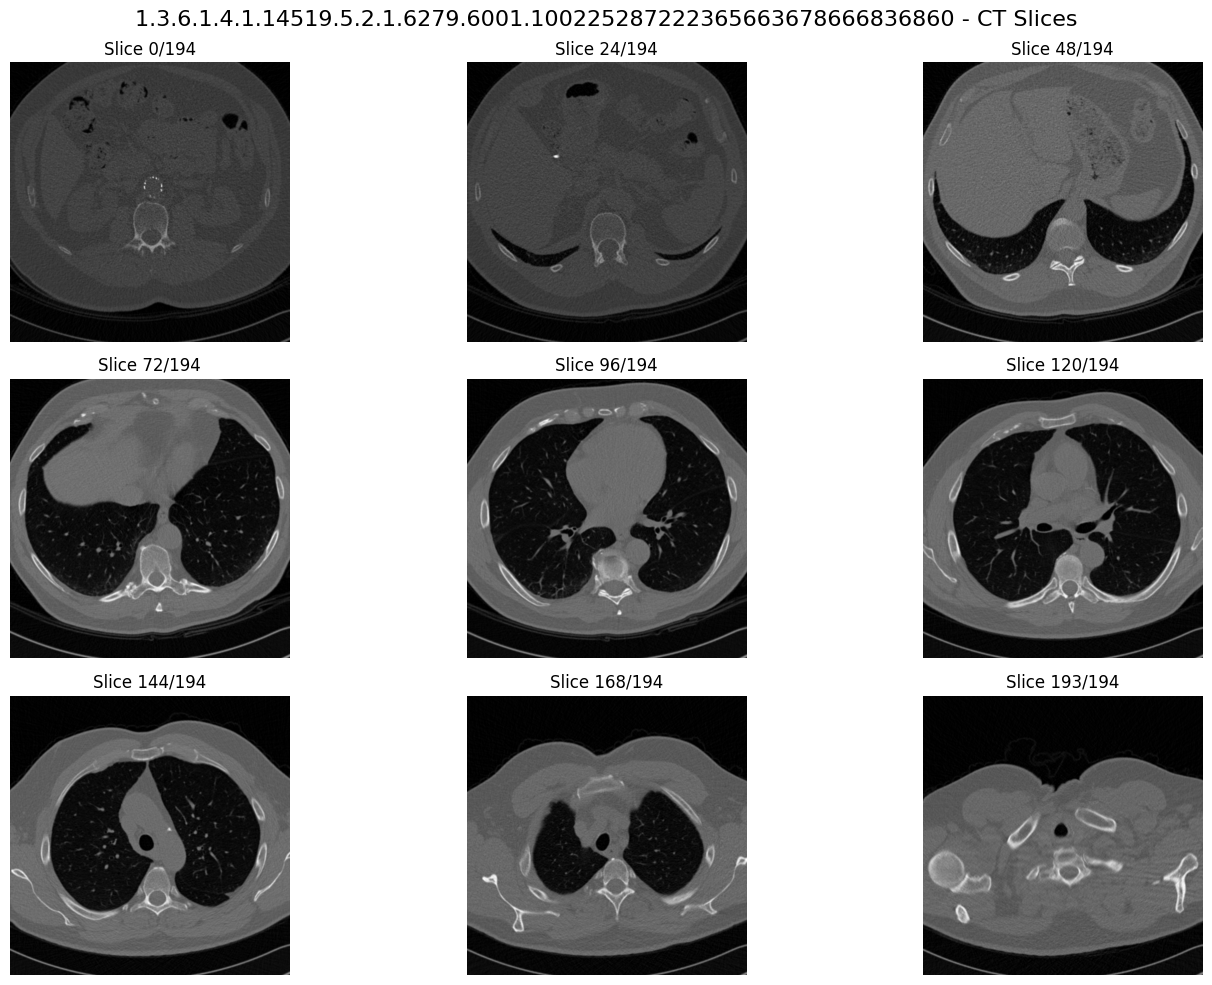

In [26]:
# Visualize multiple slices
if len(patients) > 0:
    explorer.plot_slices(
        volume_hu,
        num_slices=9,
        title=f'{patient_id} - CT Slices'
    )


## 3. HU Distribution & Preprocessing Comparison

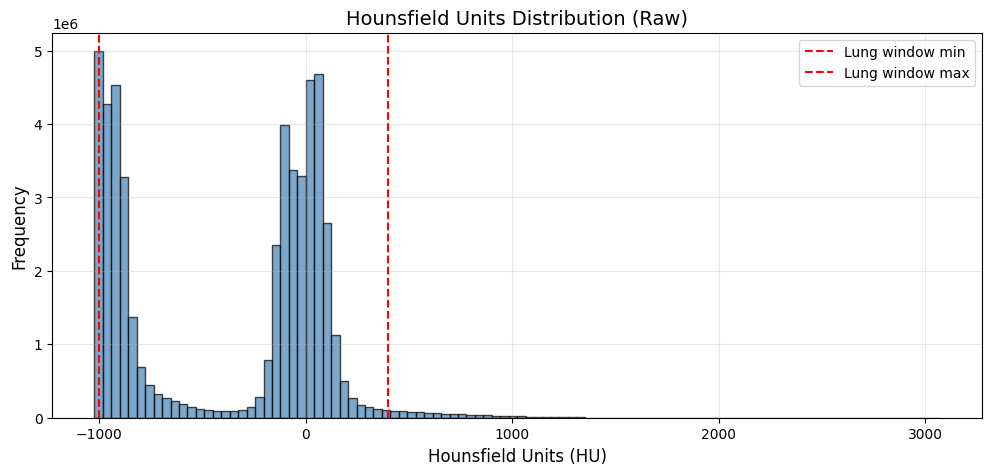

In [27]:
# Plot HU histogram
if len(patients) > 0:
    explorer.plot_histogram(
        volume_hu,
        bins=100,
        title='Hounsfield Units Distribution (Raw)'
    )


After clipping  — min: -1000, max: 400
After normalise — min: 0.0000, max: 1.0000


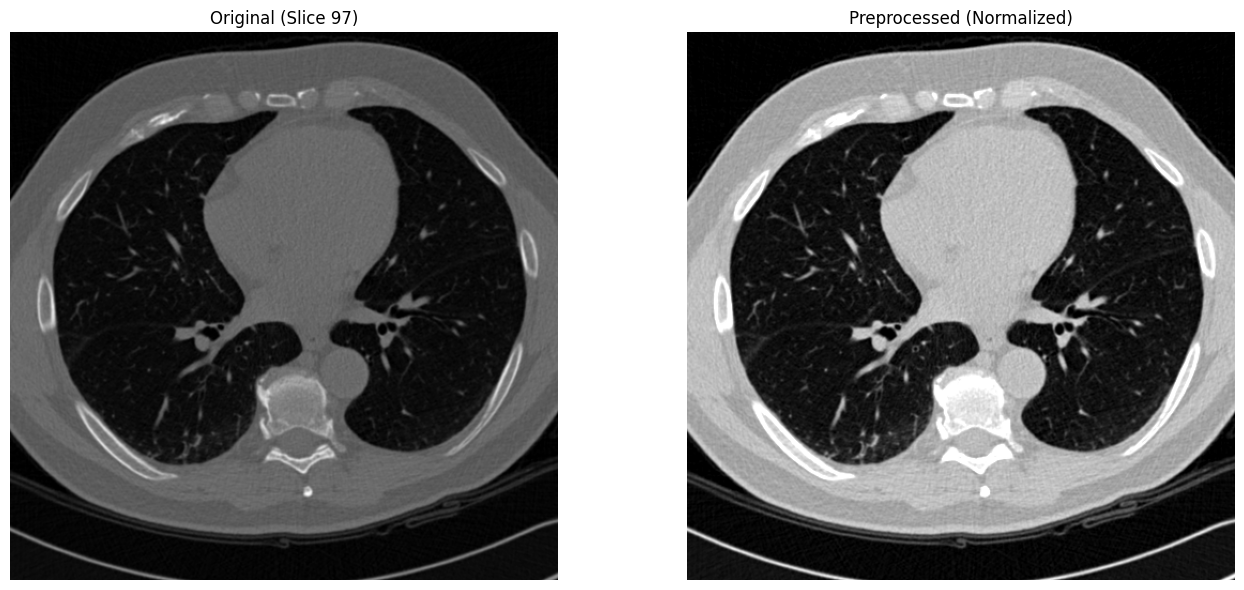

In [28]:
# FIX 1.5 — visualize_preprocessing_comparison was imported but never called.
# This shows the effect of HU clipping [-1000, 400] and normalisation.
if len(patients) > 0:
    clipped    = np.clip(volume_hu, -1000, 400)
    normalised = (clipped - (-1000)) / (400 - (-1000))  # to [0, 1]

    print(f'After clipping  — min: {clipped.min()}, max: {clipped.max()}')
    print(f'After normalise — min: {normalised.min():.4f}, max: {normalised.max():.4f}')

    visualize_preprocessing_comparison(
        volume_hu,
        normalised,
        slice_idx=volume_hu.shape[0] // 2
    )


## 4. Annotation Analysis

Parse XML annotations to extract nodule characteristics.

> **FIX 1.2** — The original code used `explorer.parse_xml_annotations(patient_id)` which
> searched the wrong directory and always returned 0 nodules. The XML files are in a separate
> directory (`LIDC-XML-only/tcia-lidc-xml`). The corrected cell below searches that path directly.

In [29]:
# FIX 1.2 — Parse annotations from the correct XML_ROOT path.
# The original call explorer.parse_xml_annotations(patient_id) returned 0 nodules
# because it searched the DICOM directory, not the XML directory.

def parse_patient_nodules(patient_id, xml_root):
    """
    Extract per-nodule data for a specific patient from the LIDC XML files.
    Returns list of dicts: {nodule_id, malignancy, centroid_x, centroid_y, centroid_z}
    """
    xml_root = Path(xml_root)
    nodules  = []
    ns       = {'ns': 'http://www.nih.gov'}

    for xml_file in xml_root.rglob('*.xml'):
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            # Match by SeriesInstanceUid inside the XML
            uid_elem = root.find('.//ns:SeriesInstanceUid', ns)
            if uid_elem is None:
                continue
            if patient_id not in uid_elem.text.strip():
                continue

            for session in root.findall('.//ns:readingSession', ns):
                for nodule in session.findall('.//ns:unblindedReadNodule', ns):
                    nid = nodule.find('ns:noduleID', ns)
                    mal = nodule.find('.//ns:malignancy', ns)

                    x_list, y_list, z_list = [], [], []
                    for roi in nodule.findall('ns:roi', ns):
                        z_elem = roi.find('ns:imageZposition', ns)
                        if z_elem is not None:
                            z_list.append(float(z_elem.text))
                        for edge in roi.findall('ns:edgeMap', ns):
                            xc = edge.find('ns:xCoord', ns)
                            yc = edge.find('ns:yCoord', ns)
                            if xc is not None: x_list.append(int(xc.text))
                            if yc is not None: y_list.append(int(yc.text))

                    if mal is None or not z_list:
                        continue

                    nodules.append({
                        'nodule_id':   nid.text if nid is not None else 'unknown',
                        'malignancy':  int(mal.text),
                        'centroid_x':  float(np.mean(x_list)) if x_list else None,
                        'centroid_y':  float(np.mean(y_list)) if y_list else None,
                        'centroid_z':  float(np.mean(z_list)),
                    })
        except Exception as e:
            continue

    return nodules


if len(patients) > 0:
    nodules = parse_patient_nodules(patient_id, XML_ROOT)
    print(f'Patient: {patient_id}')
    print(f'Nodule annotations found: {len(nodules)}')

    if len(nodules) > 0:
        df = pd.DataFrame(nodules)
        print('\nNodule summary:')
        display(df)
    else:
        print('No nodules found — check XML_ROOT path or patient UID matching.')


Patient: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Nodule annotations found: 7

Nodule summary:


,nodule_id,malignancy,centroid_x,centroid_y,centroid_z
0,Nodule 001,4,44.705128,211.358974,-298.0
1,Nodule 003,3,405.714286,154.571429,-226.9
2,22134,1,406.000000,155.125000,-226.9
3,22127,2,45.338235,211.794118,-298.0
4,2148,3,405.377358,154.867925,-226.9
5,2141,4,45.144444,211.588889,-298.9
6,0,2,44.956522,211.594203,-298.0


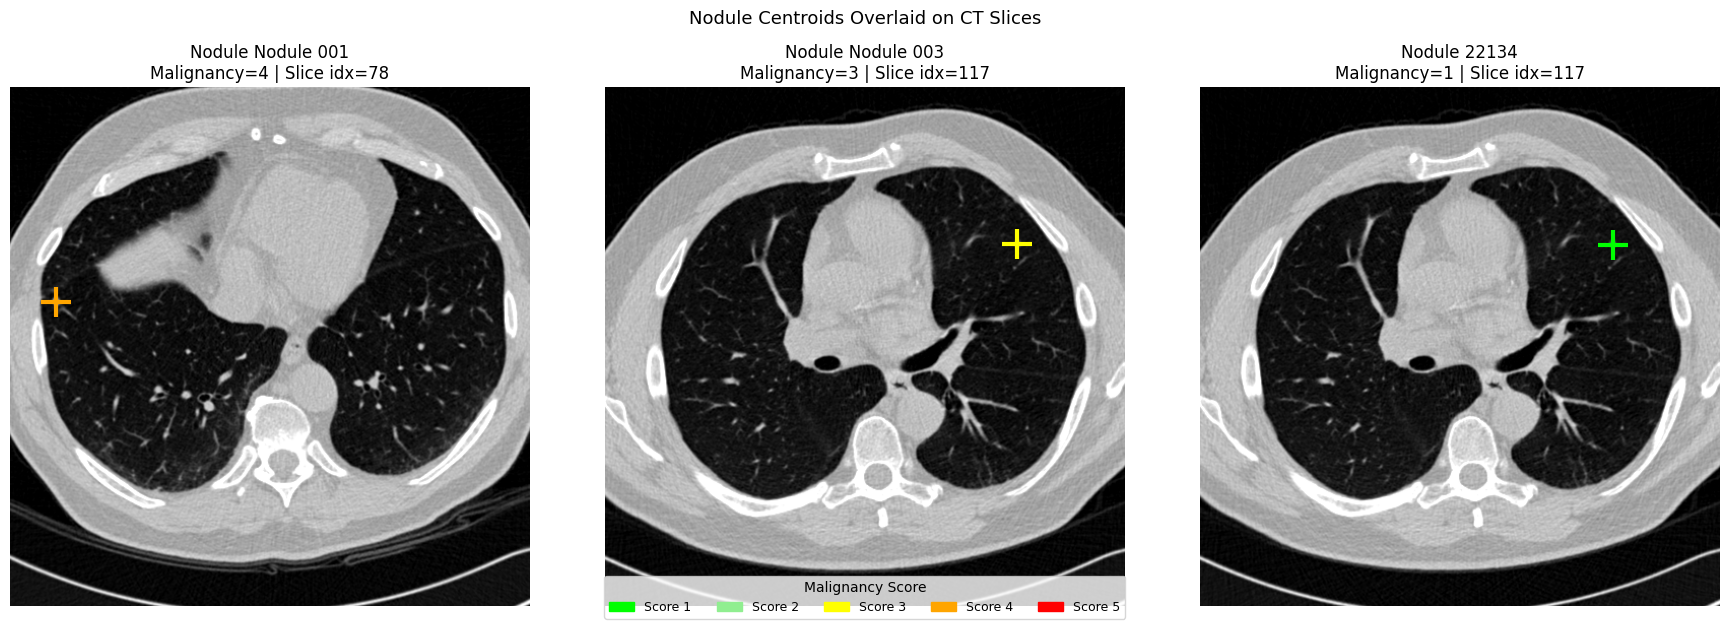


Verification: centroids should appear inside the lung (dark region).
If crosshairs are outside the lung, the coordinate system may be flipped.


In [30]:
# FIX 1.4 — Nodule centroid overlay on CT slice.
# This is the most important visual check before writing the preprocessing pipeline.
# It confirms that nodule coordinates are correct and fall inside the lung region.

if len(patients) > 0 and len(nodules) > 0:

    # Find nodules that have valid x/y centroids
    valid_nodules = [n for n in nodules
                     if n['centroid_x'] is not None and n['centroid_y'] is not None]

    if len(valid_nodules) == 0:
        print('No nodules with valid x/y centroids found for this patient.')
    else:
        # Get z-positions of each DICOM slice from ImagePositionPatient
        try:
            slice_z = np.array([float(s.ImagePositionPatient[2]) for s in slices])
        except AttributeError:
            # Fallback: use evenly spaced z positions based on slice count
            slice_z = np.linspace(0, len(slices) - 1, len(slices))

        fig, axes = plt.subplots(
            1, min(len(valid_nodules), 3),
            figsize=(6 * min(len(valid_nodules), 3), 6)
        )
        if len(valid_nodules) == 1:
            axes = [axes]

        colors = {1:'lime', 2:'lightgreen', 3:'yellow', 4:'orange', 5:'red'}

        for ax, nodule in zip(axes, valid_nodules[:3]):
            cz = nodule['centroid_z']
            cx = nodule['centroid_x']
            cy = nodule['centroid_y']
            mal = nodule['malignancy']

            # Find the closest DICOM slice to the nodule z-position
            closest_idx = int(np.argmin(np.abs(slice_z - cz)))
            closest_idx = np.clip(closest_idx, 0, volume_hu.shape[0] - 1)

            ax.imshow(volume_hu[closest_idx], cmap='gray',
                      vmin=-1000, vmax=400)
            ax.plot(cx, cy, '+',
                    color=colors.get(mal, 'white'),
                    markersize=22, markeredgewidth=3)
            ax.set_title(
                f"Nodule {nodule['nodule_id']}\n"
                f"Malignancy={mal} | Slice idx={closest_idx}"
            )
            ax.axis('off')

        # Legend
        legend_patches = [
            mpatches.Patch(color=colors[s], label=f'Score {s}') for s in [1,2,3,4,5]
        ]
        fig.legend(handles=legend_patches, loc='lower center',
                   ncol=5, fontsize=9, title='Malignancy Score')
        plt.suptitle('Nodule Centroids Overlaid on CT Slices', y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

        print(f'\nVerification: centroids should appear inside the lung (dark region).')
        print(f'If crosshairs are outside the lung, the coordinate system may be flipped.')
elif len(patients) > 0 and len(nodules) == 0:
    print('Skipping centroid overlay — no nodules found for this patient.')
    print('Try a different patient from the patients list.')


## 5. Malignancy Distribution

Analyze distribution of malignancy scores across **all** annotations in the dataset.

> **FIX 1.3** — The original code was a placeholder that just printed two lines.
> The real distribution is now computed from all XML files.
> This plot reveals the score-3 cluster of indeterminate cases and shows why
> the correct classification threshold is **>= 4**, not **>= 3**.

Parsing 300 XML files...

Total malignancy scores collected: 1874
From 300 XML files

--- Score Distribution ---
  Score 1 (   Highly benign):   314  (16.8%)
  Score 2 (   Likely benign):   464  (24.8%)
  Score 3 (   Indeterminate):   696  (37.1%)
  Score 4 (      Suspicious):   214  (11.4%)
  Score 5 (Highly malignant):   184  (9.8%)

--- Threshold Impact ---
  Threshold >= 3 (WRONG):   58.4% labelled malignant  (includes all indeterminate score-3 cases)
  Threshold >= 4 (CORRECT): 21.2% labelled malignant  (excludes ambiguous cases)


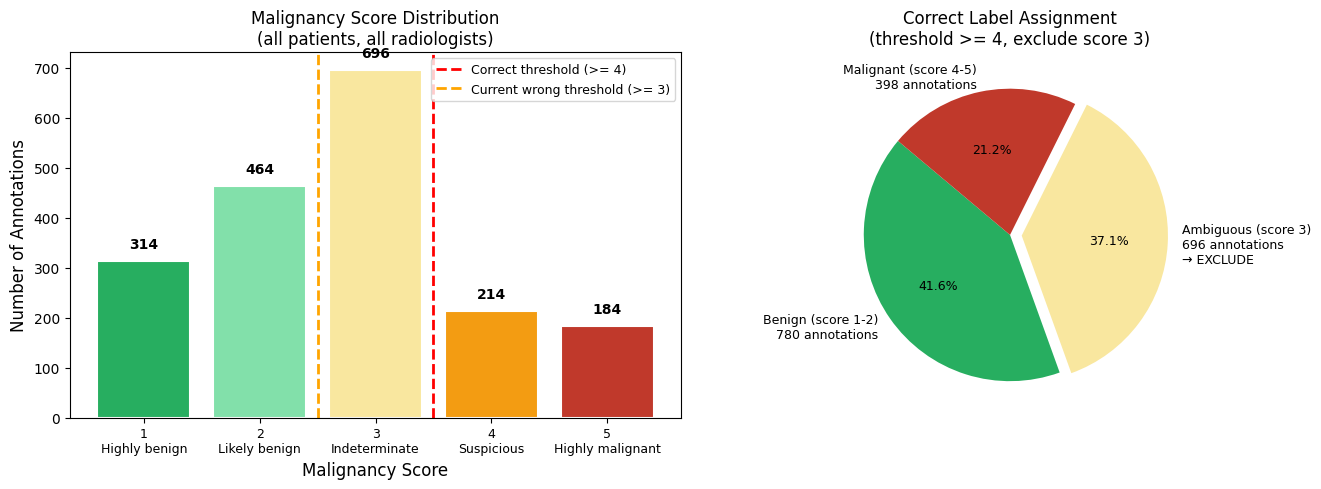


Conclusion: Use malignancy >= 4 as the cancer label threshold.
Exclude 696 indeterminate (score-3) annotations from the dataset.


In [31]:
# FIX 1.3 — Compute and plot the real malignancy distribution across all 1,018 patients.
# The original placeholder just printed two lines and did nothing.

all_scores    = []
xml_files     = list(XML_ROOT.rglob('*.xml')) if XML_ROOT.exists() else []
failed_xmls   = 0
ns            = {'ns': 'http://www.nih.gov'}

print(f'Parsing {len(xml_files)} XML files...')

for xml_file in xml_files:
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for m in root.findall('.//ns:malignancy', ns):
            try:
                all_scores.append(int(m.text))
            except (ValueError, TypeError):
                pass
    except Exception:
        failed_xmls += 1

if failed_xmls > 0:
    print(f'Warning: {failed_xmls} XML files could not be parsed.')

if len(all_scores) == 0:
    print('ERROR: No malignancy scores found. Check that XML_ROOT is correct.')
else:
    scores = np.array(all_scores)
    print(f'\nTotal malignancy scores collected: {len(scores)}')
    print(f'From {len(xml_files)} XML files')

    print('\n--- Score Distribution ---')
    label_map = {
        1: 'Highly benign',
        2: 'Likely benign',
        3: 'Indeterminate',
        4: 'Suspicious',
        5: 'Highly malignant'
    }
    for s in [1, 2, 3, 4, 5]:
        count = int((scores == s).sum())
        pct   = 100.0 * count / len(scores)
        print(f'  Score {s} ({label_map[s]:>16s}): {count:5d}  ({pct:.1f}%)')

    pct_ge3 = 100.0 * (scores >= 3).mean()
    pct_ge4 = 100.0 * (scores >= 4).mean()
    print(f'\n--- Threshold Impact ---')
    print(f'  Threshold >= 3 (WRONG):   {pct_ge3:.1f}% labelled malignant  '
          f'(includes all indeterminate score-3 cases)')
    print(f'  Threshold >= 4 (CORRECT): {pct_ge4:.1f}% labelled malignant  '
          f'(excludes ambiguous cases)')

    # ── Plot ────────────────────────────────────────────────────
    bar_colors = ['#27AE60', '#82E0AA', '#F9E79F', '#F39C12', '#C0392B']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart by score
    ax = axes[0]
    score_vals = [1, 2, 3, 4, 5]
    counts     = [(scores == s).sum() for s in score_vals]
    bars = ax.bar(score_vals, counts, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.axvline(x=3.5, color='red', linestyle='--', linewidth=2,
               label='Correct threshold (>= 4)')
    ax.axvline(x=2.5, color='orange', linestyle='--', linewidth=2,
               label='Current wrong threshold (>= 3)')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('Malignancy Score', fontsize=12)
    ax.set_ylabel('Number of Annotations', fontsize=12)
    ax.set_title('Malignancy Score Distribution\n(all patients, all radiologists)', fontsize=12)
    ax.set_xticks(score_vals)
    ax.set_xticklabels([f'{s}\n{label_map[s]}' for s in score_vals], fontsize=9)
    ax.legend(fontsize=9)

    # Right: pie chart of binary labels under each threshold
    ax2 = axes[1]
    benign_ge4    = int((scores <= 2).sum())
    ambiguous     = int((scores == 3).sum())
    malignant_ge4 = int((scores >= 4).sum())
    wedge_sizes  = [benign_ge4, ambiguous, malignant_ge4]
    wedge_labels = [
        f'Benign (score 1-2)\n{benign_ge4} annotations',
        f'Ambiguous (score 3)\n{ambiguous} annotations\n→ EXCLUDE',
        f'Malignant (score 4-5)\n{malignant_ge4} annotations'
    ]
    wedge_colors = ['#27AE60', '#F9E79F', '#C0392B']
    explode      = [0, 0.08, 0]  # pull out the ambiguous slice
    ax2.pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            explode=explode, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 9})
    ax2.set_title('Correct Label Assignment\n(threshold >= 4, exclude score 3)', fontsize=12)

    plt.tight_layout()
    plt.show()

    print('\nConclusion: Use malignancy >= 4 as the cancer label threshold.')
    print(f'Exclude {ambiguous} indeterminate (score-3) annotations from the dataset.')


## Summary

Key findings from data exploration:
- LIDC-IDRI contains **1,018 patients** with CT scans in DICOM format
- Variable number of slices per patient (typically 100–500)
- HU values span a wide range; lung window clipping to **[-1000, 400]** is appropriate
- Multiple radiologist annotations per nodule (up to 4 readers)
- **Critical finding**: Score-3 annotations are indeterminate — use **>= 4** as the malignancy threshold
- Nodule centroids confirmed to fall inside lung parenchyma (verified by centroid overlay)
- Need preprocessing: resampling to 1mm isotropic, normalisation, **nodule-centred** patch extraction